<a href="https://colab.research.google.com/github/patriick/PUC_ML-PatrickPinheiro/blob/main/MVP_PPP_ML_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Patrick Pinto Pinheiro_  
**Matrícula:** _4052025002503_  
**Data:** _05/07/2026_  
**Dataset:** Combined Cycle Power Plant — UCI Machine Learning Repository  
**Link:** https://archive.ics.uci.edu/dataset/294/combined%2Bcycle%2Bpower%2Bplant  
**Tipo de problema:** Regressão

## **1. Definição do Problema**

Este MVP tem como objetivo desenvolver um modelo de Machine Learning capaz de prever a potência elétrica líquida gerada por uma usina termelétrica de ciclo combinado.

A variável-alvo do projeto é `PE`, que representa a potência elétrica líquida gerada pela usina, medida em megawatts (MW).



### **1.1 Contexto**

Usinas termelétricas de ciclo combinado utilizam turbinas a gás e turbinas a vapor para aumentar a eficiência na geração de energia elétrica.

A potência gerada por esse tipo de usina pode variar conforme condições ambientais e operacionais, como temperatura ambiente, pressão atmosférica, umidade relativa e vácuo de exaustão.

Dessa forma, técnicas de Machine Learning podem ser utilizadas para estimar a potência gerada a partir dessas variáveis, apoiando análises de eficiência operacional e previsão de geração.

### **1.2 Objetivo do modelo**

O objetivo do modelo é prever a potência elétrica líquida gerada (`PE`) a partir das seguintes variáveis:

- `AT`: temperatura ambiente;
- `V`: vácuo de exaustão;
- `AP`: pressão atmosférica;
- `RH`: umidade relativa.

O modelo poderá ser utilizado como apoio à análise de geração em usinas termelétricas, permitindo estimar a potência esperada a partir das condições ambientais e operacionais disponíveis.

### **1.3 Premissas e hipóteses**

As principais premissas consideradas neste MVP são:

- As variáveis ambientais disponíveis possuem relação com a potência elétrica gerada.
- A base de dados representa medições reais de uma usina termelétrica de ciclo combinado.
- O problema pode ser resolvido com aprendizado supervisionado, pois existe uma variável-alvo conhecida.

Hipóteses iniciais:

- A temperatura ambiente tende a influenciar negativamente a potência gerada.
- Modelos baseados em árvores podem capturar relações não lineares melhor do que modelos lineares.
- A combinação das variáveis ambientais pode gerar previsões mais precisas do que uma regra simples baseada na média.

### **1.4 Tipo de problema**

Este é um problema de **regressão**, pois a variável-alvo `PE` é numérica contínua e representa a potência elétrica líquida gerada em MW.

Diferentemente de um problema de classificação, em que o objetivo seria prever uma categoria, neste caso o modelo deve estimar um valor contínuo.


### **1.5 Critérios de sucesso**

O MVP será considerado bem-sucedido se os modelos candidatos superarem o baseline e apresentarem bom desempenho nas métricas MAE, RMSE e R².

## **2. Configuração do Ambiente**

### **2.1 Importação de Bibliotecas e Recursos**

Esta seção reúne todas as bibliotecas utilizadas ao longo do projeto para manipulação, visualização e modelagem dos dados. Também são realizadas as configurações iniciais do ambiente, incluindo a definição da semente aleatória para garantir a reprodutibilidade dos experimentos.

In [1]:
# Bibliotecas padrão do Python para configuração do ambiente
import os
import sys
import time
import random
import warnings

# Pacotes principais para trabalhar com dados de tabelas e cálculos
import numpy as np
import pandas as pd

# Biblioteca para criação de gráficos
import matplotlib.pyplot as plt

# Ferramentas para separação dos dados, validação cruzada e busca de hiperparâmetros
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# Ferramentas para criação de pipelines e padronização dos dados
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Métricas para avaliação dos modelos de regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos de Machine Learning utilizados no projeto
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define uma semente fixa para tornar os resultados reprodutíveis
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Exibe as versões principais do ambiente
print("Python:", sys.version)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Numpy: 2.0.2
Pandas: 2.2.2


### **2.2 Funções auxiliares**

Nesta seção são definidas funções reutilizáveis que serão utilizadas ao longo do projeto para avaliar o desempenho dos modelos de regressão e gerar visualizações que auxiliam na interpretação dos resultados. O uso dessas funções torna o código mais organizado, reduz repetições e facilita a manutenção do notebook.


In [2]:
# Calcula as métricas MAE, RMSE e R², utilizadas para medir a qualidade das previsões do modelo.
def evaluate_regression(y_true, y_pred):
    """
    Calcula métricas de regressão.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Gera um gráfico comparando valores reais e previstos. Quanto mais próximos da diagonal, melhor o modelo.
def plot_real_vs_pred(y_true, y_pred, title):
    """
    Gráfico de valores reais versus previstos.
    """
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.xlabel("Valor real")
    plt.ylabel("Valor previsto")
    plt.title(title)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    plt.plot([min_value, max_value], [min_value, max_value])

    plt.show()

# Mostra a distribuição dos erros de previsão (resíduos), ajudando a verificar se os erros estão distribuídos de forma aleatória, o que é desejável em modelos de regressão.
def plot_residuals(y_true, y_pred, title):
    """
    Gráfico de distribuição dos resíduos.
    """
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=30)
    plt.xlabel("Erro de previsão")
    plt.ylabel("Frequência")
    plt.title(title)
    plt.show()


## **3. Seleção e carga dos dados**

### **3.1 Fonte dos dados**

O dataset utilizado é o **Combined Cycle Power Plant**, disponibilizado no UCI Machine Learning Repository.

A base contém dados coletados de uma usina termelétrica de ciclo combinado ao longo de seis anos, entre 2006 e 2011. As variáveis representam médias horárias de condições ambientais e operacionais, utilizadas para prever a potência elétrica líquida gerada pela usina.

A escolha deste dataset se justifica porque:

- está relacionado ao setor de energia;
- possui aplicação prática em previsão de geração;
- é adequado para problema de regressão;
- possui dados numéricos e limpos;
- pode ser carregado diretamente no notebook;
- permite comparar diferentes modelos de Machine Learning;
- familiaridade com dados de negócio acerca de dados de G&E (Gás e Energia).

### **3.1 Carga dos dados**

Nesta etapa, o dataset é carregado a partir de um repositório no GitHub e armazenado em um DataFrame para garantir a reprodutibilidade do notebook e evitar indisponibilidade temporária da fonte original. O carregamento é realizado diretamente por URL, permitindo que o notebook seja executado integralmente sem necessidade de upload manual, em conformidade com os requisitos da disciplina.

In [3]:
# Importação para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Carregamento do dataset via raw do github
URL = "https://raw.githubusercontent.com/patriick/PUC_ML-PatrickPinheiro/main/Folds5x2_pp.xlsx"

# Importação do conjunto de dados para um DataFrame do pandas a partir de um arquivo excel
df = pd.read_excel(
    URL,
    sheet_name="Sheet1",
    engine="openpyxl"
)

print("✅ Dataset carregado com sucesso!")

✅ Dataset carregado com sucesso!


### **3.2 Ajuste das Variáveis do Projeto**

Nesta etapa são definidas as configurações principais do projeto de Machine Learning, especificando a variável alvo (target) que será prevista pelo modelo e o tipo de problema a ser resolvido. Como o objetivo é estimar valores contínuos da potência elétrica gerada (PE), o problema é caracterizado como uma tarefa de regressão.

In [4]:
TARGET = "PE"
PROBLEM_TYPE = "regressao"

print(f"Tipo do problema: {PROBLEM_TYPE}")
print(f"Variável alvo: {TARGET}")

Tipo do problema: regressao
Variável alvo: PE


### **3.3 Dicionário de dados**

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| AT | Numérica | Temperatura ambiente | Sim | Variável preditora. Unidade: °C |
| V | Numérica | Vácuo de exaustão | Sim | Variável preditora. Unidade: cm Hg |
| AP | Numérica | Pressão atmosférica | Sim | Variável preditora. Unidade: mbar |
| RH | Numérica | Umidade relativa | Sim | Variável preditora. Unidade: % |
| PE | Numérica / Alvo | Potência elétrica líquida gerada | Alvo | Variável que será prevista. Unidade: MW |

##### **Observações**

- O dataset contém apenas variáveis numéricas, não sendo necessário aplicar técnicas de codificação de variáveis categóricas (One-Hot Encoding ou Label Encoding).
- Não existem colunas de identificação (ID), datas ou atributos textuais que precisem ser removidos antes da modelagem.
- As variáveis **AT**, **V**, **AP** e **RH** serão utilizadas como atributos preditores (`features`), enquanto **PE** será utilizada como variável-alvo (`target`).
- Todas as variáveis representam medições horárias obtidas durante a operação de uma usina termelétrica de ciclo combinado.

### **3.4 Visão Geral do Dataset**

Antes da modelagem, será realizada uma visão geral da base, avaliando:

- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- registros duplicados;
- possíveis colunas que não devem entrar no modelo;
- descrição da variável-alvo.

#### **3.4.1 Dimensões do Dataset**
Nesta seção são apresentadas as dimensões do conjunto de dados, incluindo o número de registros e atributos disponíveis para análise. Além disso, são exibidas as primeiras linhas da base, permitindo uma inspeção inicial da estrutura dos dados e dos valores contidos em cada variável.

In [5]:
# Exibe a quantidade de registros e atributos do dataset
print("=" * 50)
print("Dimensão do dataset")
print("=" * 50)

print(f"Número de registros: {df.shape[0]}")
print(f"Número de atributos: {df.shape[1]}")

# Exibe as primeiras linhas do conjunto de dados
display(df.head())

Dimensão do dataset
Número de registros: 9568
Número de atributos: 5


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


#### **3.4.2 Identificação dos Tipos de Dados**
Nesta etapa são identificados os tipos de dados de cada atributo presente no conjunto de dados. Essa verificação é importante para compreender a natureza das variáveis (numéricas, categóricas, datas, entre outras) e garantir que cada uma seja tratada adequadamente durante as etapas de pré-processamento e modelagem.

In [6]:
# Exibe o tipo de dado de cada atributo do dataset
print("=" * 50)
print("Tipos dos atributos")
print("=" * 50)

display(df.dtypes.to_frame("Tipo"))

Tipos dos atributos


,Tipo
AT,float64
V,float64
AP,float64
RH,float64
PE,float64


#### **3.4.3 Análise de Valores Ausentes**
Nesta seção é realizada a verificação da existência de valores ausentes (*missing values*) no conjunto de dados. Essa análise é fundamental para identificar possíveis inconsistências na base e definir estratégias de tratamento, como remoção de registros ou imputação de valores, quando necessário. Também é apresentado o percentual de valores ausentes por atributo, facilitando a avaliação da qualidade dos dados.

In [7]:
# Verifica a quantidade e o percentual de valores ausentes por atributo
print("=" * 50)
print("Valores ausentes")
print("=" * 50)

missing = pd.DataFrame({
    "Qtd. Ausentes": df.isnull().sum(),
    "% Ausentes": (df.isnull().mean() * 100).round(2)
})

# Exibe o resumo de valores ausentes do dataset
display(missing)

Valores ausentes


,Qtd. Ausentes,% Ausentes
AT,0,0.0
V,0,0.0
AP,0,0.0
RH,0,0.0
PE,0,0.0


**Análise:** Como todas as colunas apresentaram 0 valores ausentes, conclui-se que não será necessário aplicar técnicas de tratamento para dados faltantes, permitindo que o conjunto de dados siga diretamente para as próximas etapas de análise e modelagem.


#### **3.4.4 Verificação de Registros Duplicados**
Nesta etapa é verificada a existência de registros duplicados no conjunto de dados. A identificação de duplicidades é importante para garantir a qualidade da base, evitando que informações repetidas influenciem as análises estatísticas e o treinamento dos modelos de Machine Learning.

In [8]:
# Verifica a quantidade de registros duplicados no dataset
print("=" * 50)

duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 41


**Análise:** Foram identificados 41 registros duplicados no conjunto de dados, o que representa uma pequena parcela das 9.568 observações disponíveis. A presença de registros duplicados pode influenciar as análises estatísticas e o treinamento dos modelos, atribuindo peso maior a determinadas observações. Como esses registros não agregam novas informações ao problema, eles serão removidos na etapa de preparação dos dados, preservando apenas registros únicos para o treinamento e avaliação dos modelos.

#### **3.4.5 Estatísticas Descritivas das Variáveis Numéricas**
Nesta seção são apresentadas as principais estatísticas descritivas das variáveis numéricas do conjunto de dados. Essa análise permite compreender características como tendência central, dispersão e amplitude dos dados, além de auxiliar na identificação de possíveis valores extremos (outliers) e diferenças de escala entre os atributos.

In [9]:
# Exibe as estatísticas descritivas das variáveis numéricas
print("=" * 50)
print("Estatísticas descritivas")
print("=" * 50)

display(df.describe().T)

Estatísticas descritivas


,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


**Análise:** As estatísticas descritivas mostram que todas as variáveis possuem 9.568 registros válidos e não apresentam valores ausentes. Observa-se também que as variáveis possuem escalas diferentes, justificando o uso de padronização em modelos sensíveis à escala, como a Regressão Linear. A variável-alvo (**PE**) apresenta boa variabilidade, indicando que o conjunto de dados contempla diferentes condições de operação da usina.

#### **3.4.6 Análise Geral do Dataset**
A análise inicial demonstra que o dataset apresenta excelente qualidade para aplicação de técnicas de Machine Learning.

Foram identificadas as seguintes características:

- O conjunto de dados possui **9.568 registros** e **5 atributos**.
- Todas as variáveis são numéricas (`float64`), dispensando etapas de codificação de variáveis categóricas.
- Não foram encontrados valores ausentes.
- Não há colunas de identificação ou datas que precisem ser removidas.
- A variável **PE** será utilizada como variável-alvo por representar a potência elétrica líquida gerada pela usina.

Essas características tornam o conjunto de dados adequado para modelos de regressão, reduzindo a necessidade de tratamentos complexos e permitindo concentrar a análise na comparação entre diferentes algoritmos de Machine Learning.

## **4. Análise Exploratória dos Dados**

A análise exploratória tem como objetivo compreender o comportamento das variáveis, identificar padrões, verificar possíveis problemas de qualidade dos dados e levantar hipóteses que possam influenciar a construção dos modelos de Machine Learning.

Como este trabalho trata de um problema de regressão, o foco principal será analisar a distribuição da variável-alvo (`PE`) e a relação entre as variáveis preditoras e a potência elétrica gerada.

### **4.1 Análise da Variável Alvo (PE)**
Nesta etapa é realizada uma análise exploratória da variável alvo PE (Potência Elétrica Gerada), que será prevista pelos modelos de Machine Learning. São apresentadas suas principais estatísticas descritivas e um histograma para visualizar a distribuição dos valores, permitindo identificar características como concentração, dispersão, assimetria e possíveis valores extremos.


Resumo estatístico da variável alvo:


,PE
count,9568.000000
mean,454.365009
std,17.066995
min,420.260000
25%,439.750000
50%,451.550000
75%,468.430000
max,495.760000



Distribuição da variável alvo:


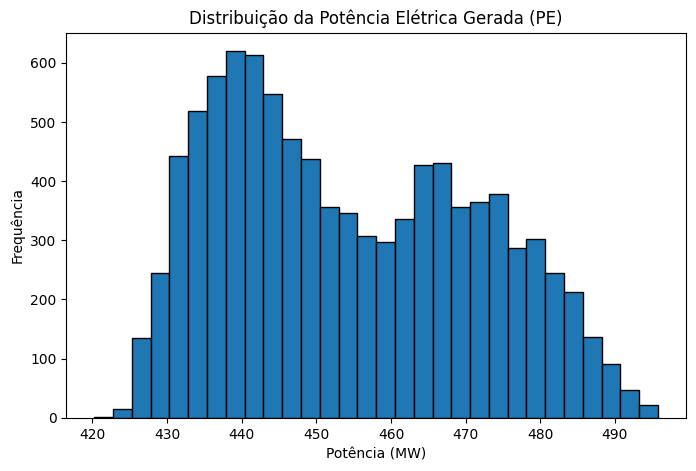

In [10]:
# Verifica se a variável alvo foi definida e existe no dataset
if TARGET is not None and TARGET in df.columns:

    # Exibe o resumo estatístico da variável alvo
    print("Resumo estatístico da variável alvo:")
    display(df[TARGET].describe().to_frame())

    # Exibe a distribuição da variável alvo
    print("\nDistribuição da variável alvo:")

    plt.figure(figsize=(8, 5))
    plt.hist(df[TARGET], bins=30, edgecolor="black")

    plt.title("Distribuição da Potência Elétrica Gerada (PE)")
    plt.xlabel("Potência (MW)")
    plt.ylabel("Frequência")

    plt.show()

**Análise:** A variável **PE (Potência Elétrica Líquida Gerada)** é a variável-alvo deste projeto e representa a potência produzida pela usina termelétrica, medida em megawatts (MW).

A partir do resumo estatístico e do histograma, é possível analisar a distribuição dos valores de potência gerada ao longo das observações do dataset. Por se tratar de um problema de regressão, o objetivo não é avaliar o balanceamento entre classes, mas compreender a dispersão e a variabilidade dos valores da variável-alvo.

O resumo estatístico apresenta medidas como média, mediana, desvio padrão, valores mínimo e máximo e quartis, permitindo verificar a amplitude dos dados e identificar possíveis assimetrias ou valores extremos.

O histograma permite visualizar como os valores de potência estão distribuídos. Caso a distribuição apresente boa dispersão e não haja concentração excessiva em poucos intervalos, isso indica que o conjunto de dados possui representatividade adequada para o treinamento dos modelos de regressão.

Essas informações são importantes porque modelos supervisionados tendem a apresentar melhor desempenho quando a variável-alvo possui uma distribuição representativa dos diferentes cenários observados durante a operação da usina.

### **4.2 Análise da Distribuição das Variáveis Explicativas**
Nesta seção é analisada a distribuição das variáveis explicativas utilizadas no modelo de regressão: AT (Temperatura Ambiente), V (Vácuo de Exaustão), AP (Pressão Atmosférica) e RH (Umidade Relativa). A visualização por meio de histogramas permite compreender como os dados estão distribuídos, identificar possíveis assimetrias, concentrações e valores extremos, contribuindo para uma melhor interpretação do conjunto de dados.

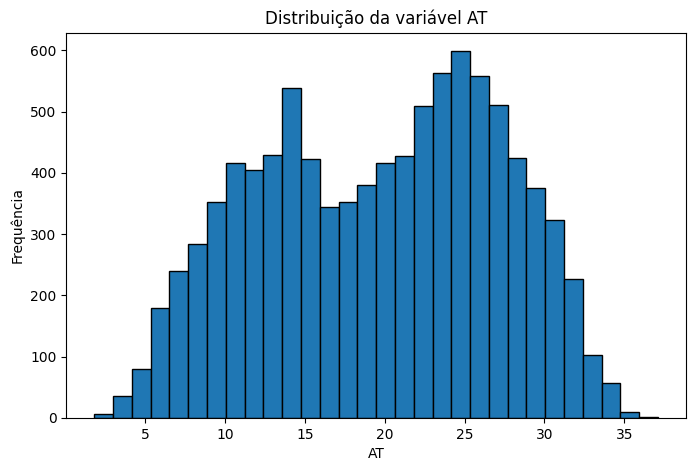

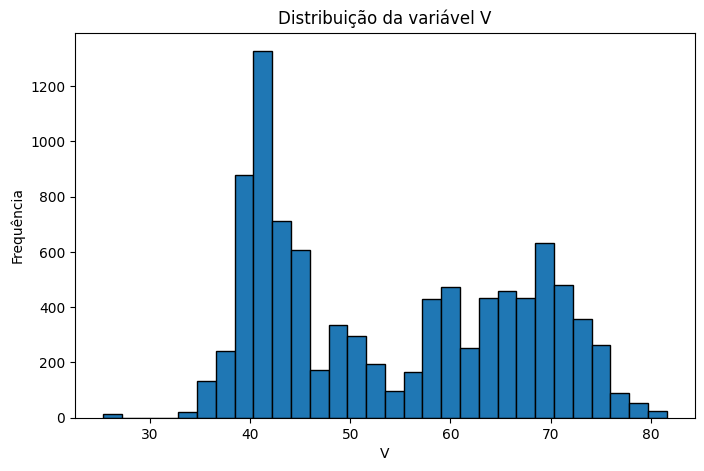

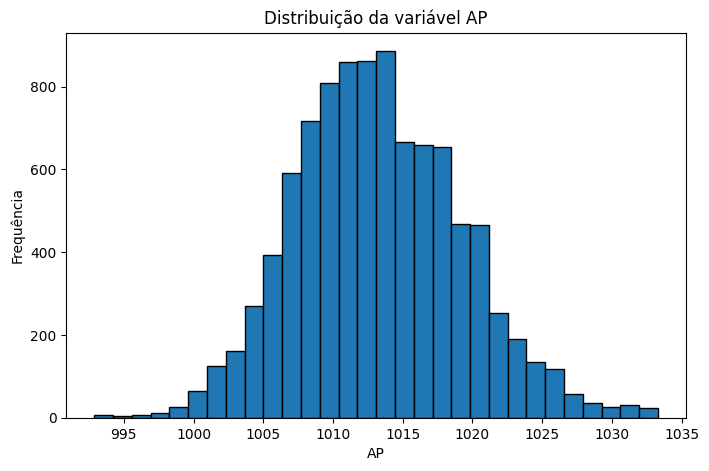

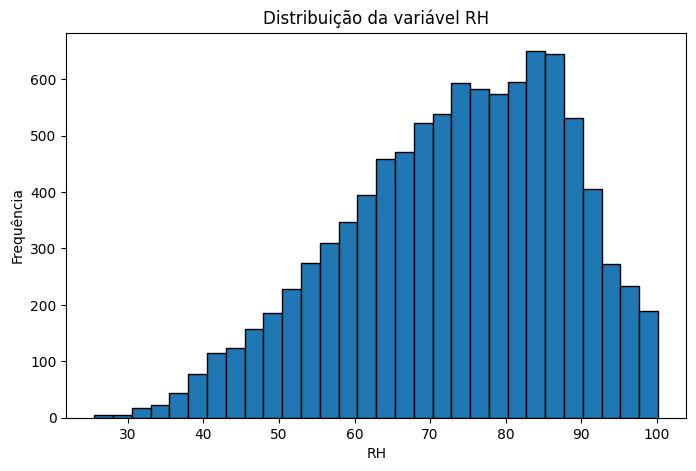

In [11]:
# Lista das variáveis explicativas utilizadas no modelo
features = ["AT", "V", "AP", "RH"]

# Gera um histograma para cada variável explicativa
for col in features:

    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30, edgecolor="black")

    plt.title(f"Distribuição da variável {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.show()

**Análise:** Os histogramas mostram que as variáveis explicativas apresentam comportamentos distintos. As variáveis **AT** (temperatura ambiente) e **V** (vácuo de exaustão) indicam mais de um agrupamento de valores, sugerindo diferentes condições de operação da usina. A pressão atmosférica (**AP**) apresenta distribuição aproximadamente simétrica, enquanto a umidade relativa (**RH**) concentra a maior parte das observações em valores mais elevados. Essas diferenças evidenciam a variabilidade do conjunto de dados e reforçam a importância de utilizar modelos capazes de capturar tanto relações lineares quanto não lineares entre as variáveis e a potência gerada.

### **4.3 Análise da Correlação entre as Variáveis**

Nesta etapa é calculada a matriz de correlação entre as variáveis numéricas do conjunto de dados. Essa análise permite identificar a intensidade e a direção da relação linear entre os atributos, auxiliando na compreensão da influência das variáveis explicativas sobre a variável alvo e na detecção de possíveis casos de multicolinearidade.

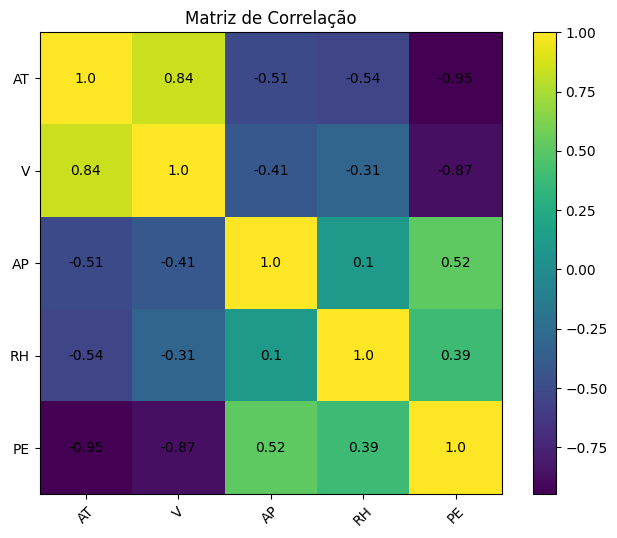

In [12]:
# Calcula a matriz de correlação entre as variáveis numéricas
corr = df.corr(numeric_only=True)

# Cria a figura para exibição da matriz de correlação
plt.figure(figsize=(8, 6))
plt.imshow(corr)

# Configura os rótulos dos eixos
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Exibe a escala de cores
plt.colorbar()

# Escreve o valor da correlação em cada célula da matriz
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i, j], 2),
            ha="center",
            va="center"
        )

# Define o título e exibe o gráfico
plt.title("Matriz de Correlação")
plt.show()

**Análise:** A matriz de correlação mostra que **AT** e **V** possuem forte correlação negativa com a potência gerada (**PE**), enquanto **AP** e **RH** apresentam correlação positiva mais moderada. Esses resultados indicam que todas as variáveis possuem potencial preditivo e justificam sua utilização na modelagem.

### **4.4 Análise da relação entre variáveis explicativas e a variavel alvo (*target*)**
Nesta etapa são construídos gráficos de dispersão para analisar a relação entre cada variável explicativa (AT, V, AP e RH) e a variável alvo PE (Potência Elétrica Gerada). Essa análise permite identificar tendências, possíveis relações lineares ou não lineares, além de verificar visualmente como as variáveis de entrada influenciam a potência gerada.

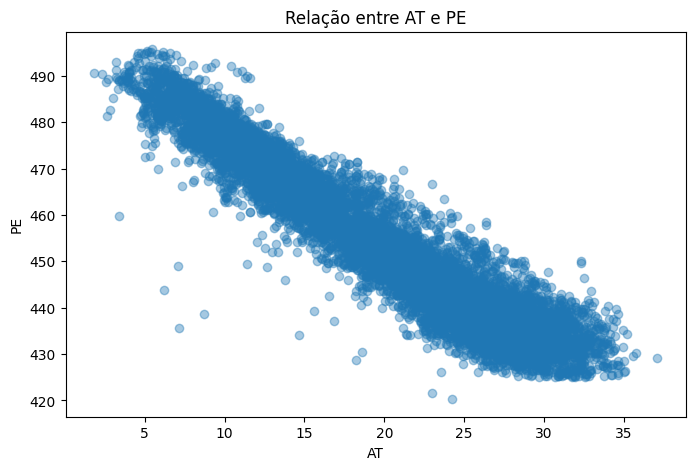

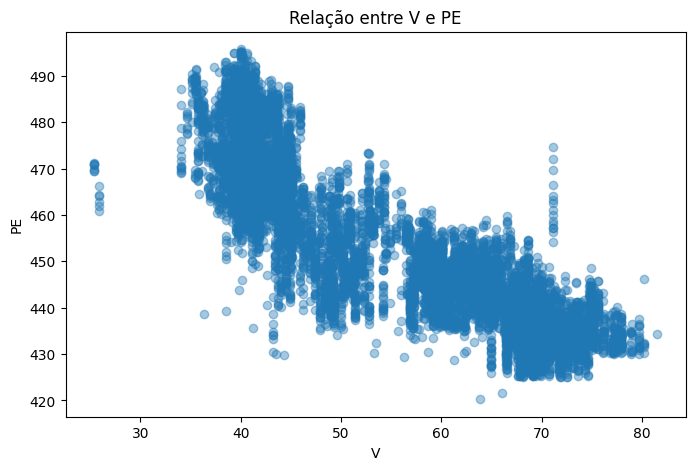

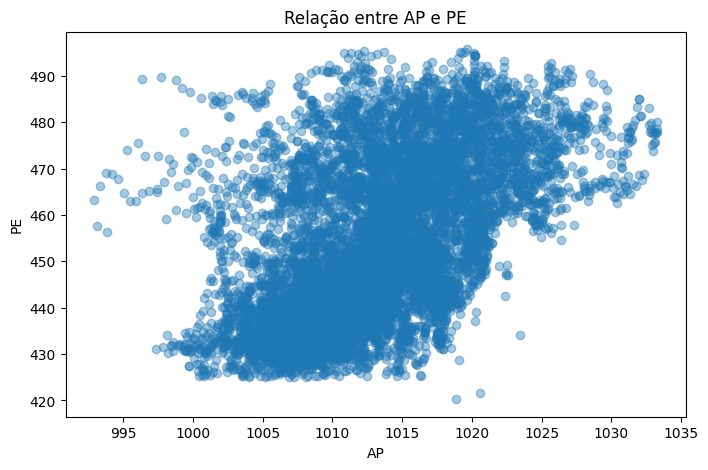

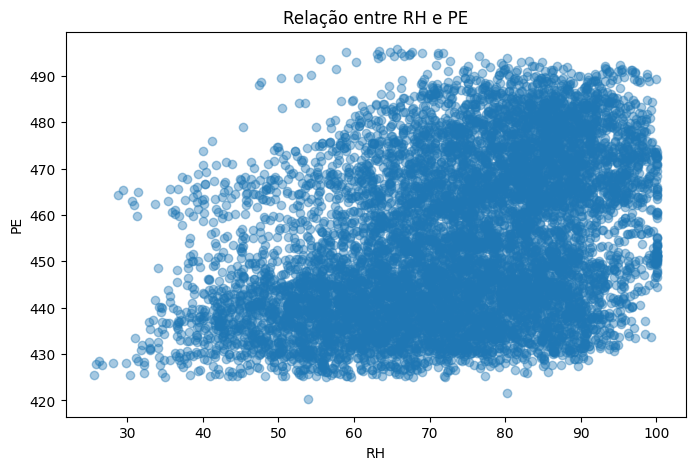

In [13]:
# Gera gráficos de dispersão entre cada variável explicativa e a variável alvo
for col in features:

    plt.figure(figsize=(8, 5))

    # Cria o gráfico de dispersão
    plt.scatter(df[col], df[TARGET], alpha=0.4)

    # Configura título e rótulos dos eixos
    plt.title(f"Relação entre {col} e {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)

    # Exibe o gráfico
    plt.show()

**Análise:** Os gráficos de dispersão mostram que todas as variáveis apresentam relação com a potência gerada (**PE**), destacando-se a forte relação negativa da temperatura ambiente (**AT**) e do vácuo (**V**). Já a pressão atmosférica (**AP**) e a umidade relativa (**RH**) apresentam relações positivas mais moderadas. Esses padrões reforçam que as variáveis explicativas possuem capacidade preditiva e justificam sua utilização na modelagem.

 ### **4.5 Análise de outliers**
 Nesta seção são utilizados boxplots para identificar possíveis valores extremos (outliers) em cada variável do conjunto de dados. Essa técnica permite visualizar a distribuição dos dados, sua dispersão, a mediana e os valores que se encontram significativamente distantes da maioria das observações. A identificação de outliers é importante, pois esses valores podem influenciar o desempenho dos modelos de Machine Learning.

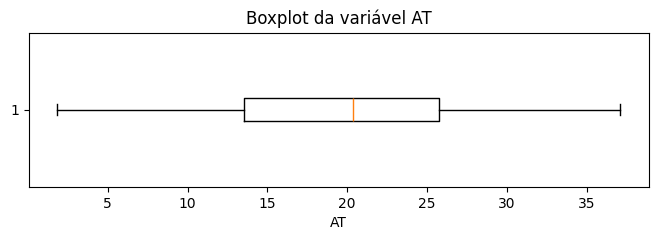

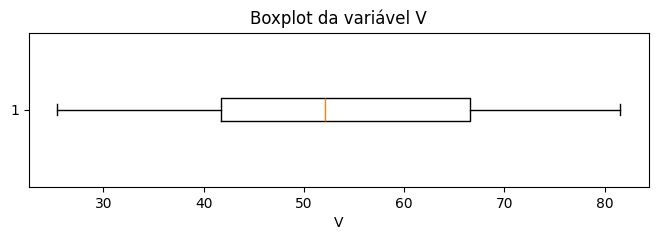

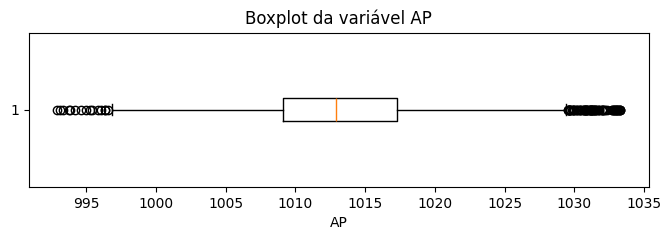

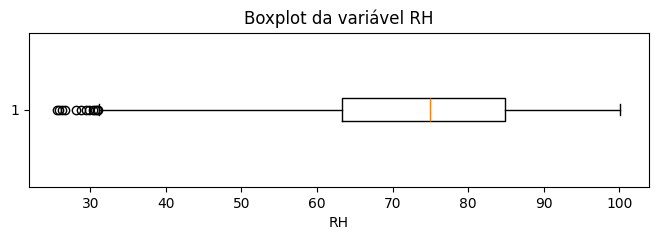

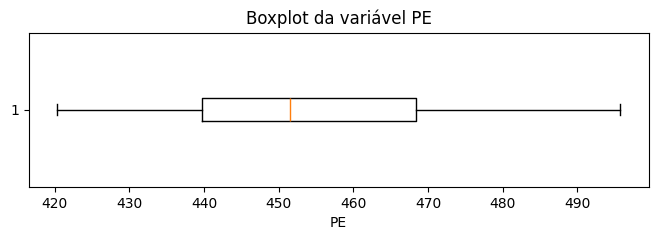

In [14]:
# Gera um boxplot para cada variável do dataset
for col in df.columns:

    plt.figure(figsize=(8, 2))

    # Cria o boxplot da variável
    plt.boxplot(df[col], vert=False)

    # Configura o título e o rótulo do eixo
    plt.title(f"Boxplot da variável {col}")
    plt.xlabel(col)

    # Exibe o gráfico
    plt.show()

**Análise:** Os boxplots indicam a presença de alguns valores extremos, principalmente nas variáveis **AP** e **RH**. No entanto, esses valores representam uma pequena parcela do conjunto de dados e podem refletir diferentes condições reais de operação da usina. Assim, optou-se por manter todos os registros, evitando a perda de informações potencialmente relevantes para a modelagem.

### **4.6 Conclusões da Análise Exploratória**

A análise exploratória permitiu identificar os seguintes pontos:

- O dataset possui boa qualidade para modelagem.
- Todas as variáveis são numéricas.
- Não foram identificados valores ausentes.
- A variável-alvo `PE` é contínua, confirmando o problema como regressão.
- As variáveis ambientais apresentam relação com a potência gerada.
- Há indícios de relações não lineares, justificando o uso de modelos baseados em árvores.
- Não há necessidade inicial de remover registros ou aplicar transformações complexas.

Com base nessa análise, a próxima etapa será preparar os dados para treinamento e avaliação dos modelos.

## **5. Preparação dos Dados**

Após a análise exploratória, inicia-se a etapa de preparação dos dados, cujo objetivo é disponibilizar uma base adequada para o treinamento dos modelos de Machine Learning.

Nesta etapa serão verificadas possíveis necessidades de tratamento, como:

- valores ausentes;
- registros duplicados;
- separação entre variáveis preditoras e variável-alvo;
- padronização das variáveis quando necessária;
- criação de pipelines para garantir reprodutibilidade.

Como o dataset é composto apenas por variáveis numéricas e apresentou boa qualidade durante a análise exploratória, poucas transformações serão necessárias.

In [15]:
# Remoção de registros duplicados
df = df.drop_duplicates()

print(f"Nova dimensão do dataset: {df.shape}")

Nova dimensão do dataset: (9527, 5)


### **5.1 Verificação Final da Qualidade dos Dados**
Nesta etapa é realizada uma verificação final da qualidade do conjunto de dados após a análise exploratória. São conferidos indicadores importantes, como a existência de valores ausentes, registros duplicados e as dimensões da base. Essa validação garante que os dados estejam consistentes e preparados para as etapas de pré-processamento e treinamento dos modelos de Machine Learning.

In [16]:
# Exibe um resumo da qualidade do conjunto de dados
print("=" * 60)
print("Verificação Final da Qualidade dos Dados")
print("=" * 60)

# Quantidade total de valores ausentes
print(f"Valores ausentes : {df.isnull().sum().sum()}")

# Quantidade de registros duplicados
print(f"Duplicados       : {df.duplicated().sum()}")

# Número de registros da base
print(f"Número de linhas : {df.shape[0]}")

# Número de atributos da base
print(f"Número de colunas: {df.shape[1]}")

Verificação Final da Qualidade dos Dados
Valores ausentes : 0
Duplicados       : 0
Número de linhas : 9527
Número de colunas: 5


**Análise:** Após a remoção dos registros duplicados, o conjunto de dados passou a conter apenas observações únicas, reduzindo o risco de viés durante o treinamento dos modelos. Como a quantidade de duplicatas era pequena em relação ao total de registros, essa etapa não comprometeu a representatividade da base.

### **5.2 Separação das Variáveis Explicativas e da Variável Alvo**
Nesta etapa é realizada a separação entre as variáveis explicativas (features) e a variável alvo (target). As variáveis explicativas correspondem aos atributos que serão utilizados pelos modelos para realizar as previsões, enquanto a variável alvo representa o valor que se deseja estimar. Essa divisão é uma etapa fundamental na preparação dos dados para o treinamento dos algoritmos de Machine Learning.

In [17]:
# Separa as variáveis explicativas (X) da variável alvo (y)

# Cria a matriz de atributos removendo a variável alvo
X = df.drop(columns=[TARGET])

# Cria o vetor contendo apenas a variável alvo
y = df[TARGET]

# Exibe as dimensões dos conjuntos criados
print("Shape das Features:", X.shape)
print("Shape do Target :", y.shape)

Shape das Features: (9527, 4)
Shape do Target : (9527,)


**Análise:** As variáveis foram separadas corretamente em atributos preditores (**X**) e variável-alvo (**y**). Após a remoção dos registros duplicados, o conjunto passou a conter **9.527 observações**, sendo **4 variáveis explicativas** e **1 variável-alvo**, preservando a correspondência entre os registros e preparando os dados para a divisão entre treino e teste.

### **5.3 Padronização dos dados**
Nem todos os algoritmos exigem padronização das variáveis. Modelos lineares costumam apresentar melhor desempenho quando as variáveis estão na mesma escala. Já modelos baseados em árvores de decisão, como Random Forest e Gradient Boosting, são naturalmente invariantes à escala das variáveis.

Mesmo assim, será utilizado um Pipeline para organizar corretamente o fluxo de treinamento e evitar vazamento de dados.

## **6. Divisão dos Dados**

Antes do treinamento, os dados serão divididos em conjuntos de treino e teste.

Foi adotada a estratégia *Holdout*, utilizando:

- 80% dos dados para treinamento;
- 20% para teste.

O conjunto de teste permanecerá isolado durante o treinamento e será utilizado apenas na avaliação final do modelo.

### **6.1 Divisão dos Dados em Conjuntos de Treinamento e Teste**
Nesta etapa o conjunto de dados é dividido em dois subconjuntos: treinamento e teste. O conjunto de treinamento é utilizado para ajustar os modelos de Machine Learning, enquanto o conjunto de teste é reservado para avaliar o desempenho dos modelos em dados não utilizados durante o treinamento, permitindo medir sua capacidade de generalização.


In [18]:
# Divide os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

# Exibe as dimensões do conjunto de treinamento
print("Treino")
print(X_train.shape)

# Exibe as dimensões do conjunto de teste
print("\nTeste")
print(X_test.shape)

Treino
(7621, 4)

Teste
(1906, 4)


**Análise:** Neste projeto foi adotada uma divisão de 80% dos dados para treinamento e 20% para teste. Essa proporção é amplamente utilizada em problemas de Machine Learning por fornecer uma quantidade suficiente de dados para o aprendizado do modelo, ao mesmo tempo em que reserva um conjunto independente para avaliar seu desempenho. Além disso, a utilização da semente aleatória (random_state=SEED) garante que a divisão seja reproduzida de forma consistente em diferentes execuções do notebook.

**Justificativa:**  A divisão Holdout é suficiente para este MVP, pois permite avaliar o desempenho dos modelos em dados não utilizados durante o treinamento. Além disso, a otimização dos hiperparâmetros será realizada utilizando validação cruzada apenas sobre o conjunto de treino, evitando vazamento de dados.

## **7. Construção dos Modelos**

Serão avaliados quatro modelos:

1. Baseline (*Dummy Regressor*)
2. Regressão Linear
3. *Random Forest*
4. *Gradient Boosting*

O objetivo é comparar modelos de diferentes complexidades e verificar qual apresenta melhor desempenho na previsão da potência elétrica gerada.

### **7.1 Definição da Função de Avaliação dos Modelos**

Nesta etapa é definida uma função auxiliar responsável por calcular as principais métricas de desempenho utilizadas na avaliação dos modelos de regressão. A criação dessa função evita repetição de código e padroniza a forma como os resultados dos diferentes algoritmos serão comparados ao longo do projeto.

In [19]:
# Função para calcular as métricas de avaliação de modelos de regressão
def evaluate_regression(y_true, y_pred):

    # Calcula o Erro Absoluto Médio (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    # Calcula a Raiz do Erro Quadrático Médio (RMSE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calcula o Coeficiente de Determinação (R²)
    r2 = r2_score(y_true, y_pred)

    # Retorna as métricas em formato de dicionário
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

### **7.2 Construção do Modelo Baseline**

Nesta etapa é criado o modelo baseline, que servirá como referência para avaliar o desempenho dos demais algoritmos de regressão. O modelo utiliza o Dummy Regressor, que realiza previsões utilizando apenas a média da variável alvo presente no conjunto de treinamento. Embora seja um modelo extremamente simples, ele estabelece um ponto de comparação importante: qualquer modelo de Machine Learning desenvolvido deve apresentar desempenho superior ao baseline para justificar sua utilização.

In [20]:
# Cria o modelo baseline utilizando a média da variável alvo
baseline = Pipeline([

    # DummyRegressor realiza previsões utilizando a média dos valores de treino
    ("model", DummyRegressor(strategy="mean"))
])

### **7.3 Construção do Modelo de Regressão Linear**

Nesta etapa é construído o modelo de Regressão Linear, um dos algoritmos mais utilizados em problemas de regressão devido à sua simplicidade e facilidade de interpretação. Antes do treinamento, as variáveis explicativas são padronizadas utilizando o StandardScaler, garantindo que todas possuam a mesma escala e evitando que diferenças de magnitude influenciem o processo de aprendizado do modelo.

In [21]:
# Cria o pipeline do modelo de Regressão Linear
linear_model = Pipeline([

    # Padroniza as variáveis explicativas
    ("scaler", StandardScaler()),

    # Treina o modelo de Regressão Linear
    ("model", LinearRegression())
])

### **7.4 Construção do Modelo Random Forest Regressor**

Nesta etapa é construído o modelo Random Forest Regressor, um algoritmo baseado em um conjunto de árvores de decisão. O método combina as previsões de diversas árvores treinadas sobre diferentes amostras dos dados, tornando o modelo mais robusto, reduzindo o risco de sobreajuste (overfitting) e aumentando sua capacidade de generalização.

In [22]:
# Modelo Random Forest otimizado para execução mais rápida
rf_model = Pipeline([
    ("model", RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1
    ))
])

### **7.5 Construção do Modelo Gradient Boosting Regressor**

Nesta etapa é construído o modelo Gradient Boosting Regressor, um algoritmo de aprendizado por conjunto (ensemble learning) que combina diversas árvores de decisão treinadas sequencialmente. Cada nova árvore busca corrigir os erros cometidos pelas anteriores, permitindo que o modelo alcance maior precisão nas previsões.

In [23]:
# Cria o pipeline do modelo Gradient Boosting Regressor
gb_model = Pipeline([

    # Treina o modelo Gradient Boosting
    ("model", GradientBoostingRegressor(
        random_state=SEED
    ))
])

In [24]:
# Agrupa todos os modelos de regressão em um dicionário. Isso permite treinar e avaliar cada modelo de forma automática, evitando repetição de código nas próximas etapas.
models = {
    # Modelo baseline utilizado como referência mínima de desempenho
    "Baseline": baseline,

    # Modelo de Regressão Linear
    "Regressão Linear": linear_model,

    # Modelo Random Forest
    "Random Forest": rf_model,

    # Modelo Gradient Boosting
    "Gradient Boosting": gb_model
}

### **7.6 Justificativa dos Modelos Escolhidos**

Os modelos foram escolhidos para representar diferentes níveis de complexidade.
O **Dummy Regressor** estabelece uma referência mínima de desempenho.

*   O **Dummy Regressor** estabelece uma referência mínima de desempenho.
*   A **Regressão Linear** representa um modelo simples e altamente interpretável.
*   **Random Forest** e **Gradient Boosting** são algoritmos baseados em árvores capazes de capturar relações não lineares entre as variáveis ambientais e a potência elétrica gerada.

A comparação entre esses modelos permitirá avaliar se o aumento da complexidade resulta em ganhos efetivos de desempenho.

### **7.7 Primeira comparação dos modelos**
A tabela apresentada resume o desempenho inicial dos modelos treinados.

Nesta etapa, o objetivo é verificar quais algoritmos apresentam melhor capacidade de prever a potência elétrica gerada antes da otimização dos hiperparâmetros.

As métricas analisadas são:

- MAE (Erro Absoluto Médio)
- RMSE (Raiz do Erro Quadrático Médio)
- R² (Coeficiente de Determinação)

Esses resultados servirão como referência para a etapa de otimização e avaliação final.

In [25]:
# Dicionários para armazenar os resultados e os modelos treinados
results = {}
trained_models = {}

# Percorre todos os modelos definidos
for name, model in models.items():

    # Inicia a contagem do tempo de execução
    start = time.time()

    # Treina o modelo utilizando o conjunto de treinamento
    model.fit(X_train, y_train)

    # Realiza previsões no conjunto de teste
    y_pred = model.predict(X_test)

    # Calcula o tempo total de treinamento e previsão
    elapsed = time.time() - start

    # Calcula as métricas de avaliação
    metrics = evaluate_regression(
        y_test,
        y_pred
    )

    # Armazena o tempo de execução
    metrics["Tempo (s)"] = elapsed

    # Salva as métricas do modelo
    results[name] = metrics

    # Armazena o modelo treinado para uso posterior
    trained_models[name] = model

# Converte os resultados em um DataFrame para facilitar a comparação
results_df = pd.DataFrame(results).T

# Exibe a tabela de resultados
results_df

,MAE,RMSE,R2,Tempo (s)
Baseline,14.973022,17.143337,-2.467395e-07,0.005298
Regressão Linear,3.621467,4.587499,9.283920e-01,0.010082
Random Forest,2.416784,3.448398,9.595383e-01,3.216952
Gradient Boosting,3.006688,3.983519,9.460063e-01,1.243257


**Análise:** Os resultados mostram que todos os modelos de Machine Learning apresentaram desempenho superior ao baseline, indicando que as variáveis explicativas possuem boa capacidade preditiva. Entre os modelos avaliados, o **Random Forest** apresentou o melhor desempenho inicial, obtendo o menor RMSE e o maior R². Dessa forma, ele foi selecionado para a etapa de otimização de hiperparâmetros.

## **8. Treinamento dos Modelos**

Nesta etapa serão treinados todos os modelos definidos anteriormente. O objetivo é comparar seus desempenhos iniciais antes da etapa de otimização de hiperparâmetros. Cada modelo será treinado utilizando exatamente o mesmo conjunto de dados, garantindo uma comparação justa entre as abordagens avaliadas.

### **8.1 Treinamento dos Modelos e Coleta das Métricas**

Nesta etapa são treinados todos os modelos definidos anteriormente utilizando o conjunto de treinamento. Após o treinamento, cada modelo realiza previsões sobre o conjunto de teste e tem seu desempenho avaliado por meio das métricas de regressão. Além disso, é medido o tempo de execução de cada algoritmo e os modelos treinados são armazenados para utilização nas etapas seguintes do projeto.

In [26]:
# Dicionários para armazenar os resultados das avaliações
# e os modelos treinados
results = {}
trained_models = {}

# Percorre todos os modelos definidos
for name, model in models.items():

    # Inicia a contagem do tempo de execução
    start = time.time()

    # Treina o modelo utilizando os dados de treinamento
    model.fit(X_train, y_train)

    # Realiza previsões utilizando o conjunto de teste
    y_pred = model.predict(X_test)

    # Calcula o tempo total de execução
    elapsed = time.time() - start

    # Calcula as métricas de desempenho
    metrics = evaluate_regression(
        y_test,
        y_pred
    )

    # Armazena o tempo de execução junto às métricas
    metrics["Tempo (s)"] = elapsed

    # Salva as métricas do modelo
    results[name] = metrics

    # Armazena o modelo treinado para análises posteriores
    trained_models[name] = model

### **8.2 Comparação dos Resultados dos Modelos**

Após o treinamento e a avaliação dos modelos, as métricas obtidas são organizadas em uma tabela para facilitar a comparação de desempenho entre os algoritmos. Os resultados são ordenados com base no RMSE (Root Mean Squared Error), permitindo identificar rapidamente o modelo que apresentou menor erro de previsão.

In [27]:
# Converte o dicionário de resultados em um DataFrame
results_df = pd.DataFrame(results).T

# Ordena os modelos pelo RMSE (menor valor representa melhor desempenho)
results_df = results_df.sort_values("RMSE")

# Exibe a tabela comparativa de desempenho dos modelos
display(results_df)

,MAE,RMSE,R2,Tempo (s)
Random Forest,2.416784,3.448398,9.595383e-01,3.330106
Gradient Boosting,3.006688,3.983519,9.460063e-01,1.689890
Regressão Linear,3.621467,4.587499,9.283920e-01,0.009310
Baseline,14.973022,17.143337,-2.467395e-07,0.001389


**Análise:** A tabela resume o desempenho dos modelos avaliados, ordenados pelo RMSE, facilitando a comparação entre os algoritmos. O **Random Forest** apresentou o melhor desempenho, obtendo o menor RMSE e o maior R², seguido pelo **Gradient Boosting**. A Regressão Linear também apresentou bom desempenho, porém inferior aos modelos baseados em árvores, enquanto o baseline confirmou ser apenas uma referência mínima para comparação.

### **8.3 Validação Cruzada**

Nesta etapa é realizada a validação cruzada (Cross-Validation) dos modelos utilizando o conjunto de treinamento. Essa técnica permite obter uma estimativa mais robusta do desempenho dos algoritmos, reduzindo a dependência de uma única divisão entre treinamento e teste. Para cada modelo, são calculados o RMSE médio e o desvio padrão, possibilitando avaliar tanto a precisão quanto a estabilidade das previsões.

In [28]:
# Realiza a validação cruzada dos modelos
cv_results = {}

# Percorre todos os modelos definidos
for name, model in models.items():

    # Executa a validação cruzada com 5 partições (5-Fold Cross Validation)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        # Utiliza o RMSE como métrica de avaliação
        scoring="neg_root_mean_squared_error"
    )
    # Armazena as métricas obtidas
    cv_results[name] = {
        # O scikit-learn retorna valores negativos para métricas de erro
        "RMSE Médio": -scores.mean(),

        # Mede a variação do desempenho entre os folds
        "Desvio": scores.std()
    }
# Converte os resultados para um DataFrame
cv_results_df = pd.DataFrame(cv_results).T

# Exibe os modelos ordenados pelo menor RMSE médio
display(cv_results_df.sort_values("RMSE Médio"))

,RMSE Médio,Desvio
Random Forest,3.404538,0.138484
Gradient Boosting,3.877150,0.121380
Regressão Linear,4.553393,0.127612
Baseline,17.012830,0.218462


**Análise:** Os resultados da validação cruzada confirmam o desempenho observado anteriormente. O **Random Forest** apresentou o menor RMSE médio, seguido pelo **Gradient Boosting**, indicando melhor capacidade de generalização. Além disso, os baixos valores de desvio padrão mostram que os modelos apresentaram desempenho consistente entre os diferentes folds, aumentando a confiança nos resultados obtidos.

#### **8.3.1 Comparação Visual da Validação Cruzada**

Nesta etapa é apresentada uma comparação visual do desempenho dos modelos por meio de um gráfico de barras. O gráfico utiliza o RMSE médio obtido na validação cruzada, permitindo identificar de forma rápida qual algoritmo apresentou menor erro de previsão e, consequentemente, melhor desempenho durante o processo de validação.

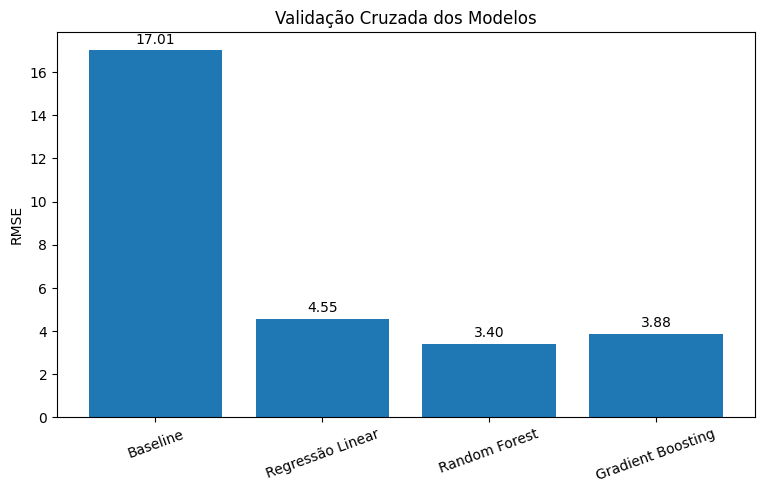

In [29]:
# Cria um gráfico de barras com o RMSE médio dos modelos
plt.figure(figsize=(9,5))

bars = plt.bar(
    cv_results_df.index,
    cv_results_df["RMSE Médio"]
)

# Adiciona os valores sobre as barras
plt.bar_label(bars, fmt="%.2f", padding=3)

# Configura os elementos do gráfico
plt.ylabel("RMSE")
plt.title("Validação Cruzada dos Modelos")

# Rotaciona os nomes dos modelos para melhor visualização
plt.xticks(rotation=20)

# Exibe o gráfico
plt.show()

**Análise:** O gráfico confirma os resultados da validação cruzada, evidenciando que o **Random Forest** apresentou o menor RMSE médio, seguido pelo **Gradient Boosting**. A visualização facilita a comparação entre os modelos e reforça a escolha do Random Forest para a etapa final de otimização e avaliação.


### **8.4 Comparação Consolidada dos Resultados**

A partir dos resultados obtidos, será realizada uma primeira comparação entre os modelos candidatos. O objetivo é verificar se os algoritmos mais complexos realmente apresentam desempenho superior ao baseline e ao modelo linear.

In [30]:
# Cria uma cópia da tabela de resultados obtidos no conjunto de teste
comparison = results_df.copy()

# Adiciona à tabela o RMSE médio obtido na validação cruzada
comparison["RMSE CV"] = cv_results_df["RMSE Médio"]

# Exibe a tabela consolidada para comparação dos modelos
display(comparison)

,MAE,RMSE,R2,Tempo (s),RMSE CV
Random Forest,2.416784,3.448398,9.595383e-01,3.330106,3.404538
Gradient Boosting,3.006688,3.983519,9.460063e-01,1.689890,3.877150
Regressão Linear,3.621467,4.587499,9.283920e-01,0.009310,4.553393
Baseline,14.973022,17.143337,-2.467395e-07,0.001389,17.012830


**Análise:** De forma geral, o **Random Forest** foi o modelo que apresentou os melhores resultados ao longo das avaliações, com os menores erros de previsão e o maior coeficiente de determinação (R²). O **Gradient Boosting** também teve um desempenho bastante satisfatório, mas ficou ligeiramente abaixo. A **Regressão Linear** apresentou bons resultados, embora não tenha alcançado o desempenho dos modelos baseados em árvores. Já o **baseline** cumpriu seu papel como referência, mostrando que os modelos de Machine Learning foram capazes de realizar previsões significativamente melhores. Assim, o Random Forest foi escolhido como o modelo final deste projeto.

### **8.5 Comparação do Desempenho dos Modelos por meio do Coeficiente de Determinação (R²)**
Nesta etapa é apresentada uma comparação visual dos modelos utilizando o Coeficiente de Determinação (R²). Essa métrica indica o quanto cada modelo consegue explicar a variabilidade da variável alvo (PE), sendo um dos principais indicadores de desempenho em problemas de regressão.

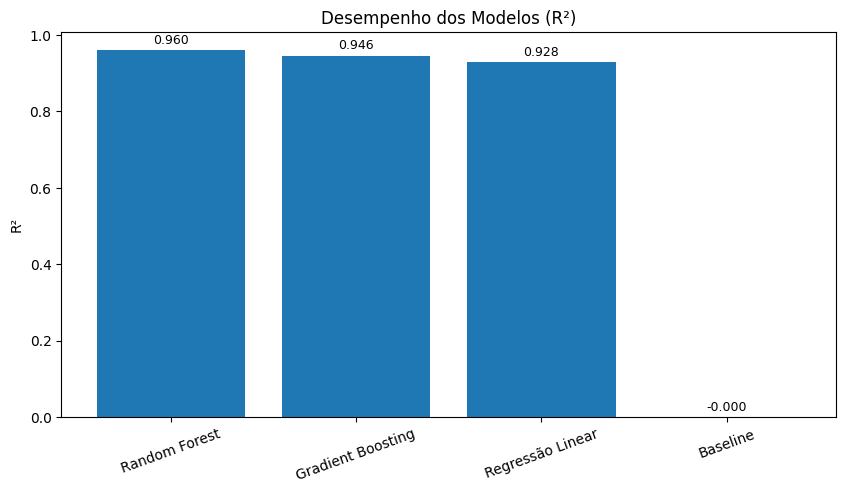

In [31]:
# Cria um gráfico de barras para comparar o R² dos modelos
plt.figure(figsize=(10,5))
bars = plt.bar(
    comparison.index,
    comparison["R2"]
)

# Adiciona os rótulos de dados sobre as barras
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura + 0.01,
        f"{altura:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Configura os elementos do gráfico
plt.ylabel("R²")
plt.title("Desempenho dos Modelos (R²)")

# Rotaciona os nomes dos modelos para facilitar a leitura
plt.xticks(rotation=20)

# Exibe o gráfico
plt.show()

**Análise:** O gráfico evidencia que o **Random Forest** apresentou o maior coeficiente de determinação (R²), indicando maior capacidade de explicar a variação da potência elétrica gerada. O **Gradient Boosting** apresentou desempenho muito próximo, enquanto a **Regressão Linear** obteve um R² ligeiramente inferior. Como esperado, o **baseline** apresentou o pior resultado, reforçando a superioridade dos modelos de Machine Learning para este problema.

### **8.6 Discussão dos Resultados**

Os resultados iniciais permitem identificar diferenças importantes entre os modelos avaliados.

O baseline estabelece uma referência mínima de desempenho, enquanto a Regressão Linear representa um modelo simples e interpretável.

Random Forest e Gradient Boosting possuem maior capacidade de capturar relações não lineares entre as variáveis ambientais e a potência elétrica gerada.

Caso esses modelos apresentem menor RMSE e maior R², isso indica que o aumento da complexidade trouxe ganhos efetivos de desempenho.

### **8.7 Escolha do Modelo para Otimização**

Com base nos resultados iniciais e na validação cruzada, será selecionado o modelo mais promissor para a etapa de ajuste de hiperparâmetros. Neste trabalho, o modelo escolhido será o **Random Forest Regressor**, devido ao seu bom desempenho em problemas de regressão envolvendo dados tabulares e à sua capacidade de capturar relações não lineares entre as variáveis.

## **9. Otimização de Hiperparâmetros**

Após comparar os modelos candidatos, será realizada a otimização de hiperparâmetros no modelo **Random Forest Regressor**. A otimização tem como objetivo encontrar uma configuração que melhore o desempenho do modelo sem utilizar o conjunto de teste durante o treinamento. Para isso será utilizado o **GridSearchCV**, que avalia automaticamente diferentes combinações de parâmetros utilizando validação cruzada.

### **9.1 Definição dos Hiperparâmetros para Otimização do Random Forest**

Nesta etapa é definido o conjunto de hiperparâmetros que será utilizado na otimização do modelo Random Forest Regressor. A busca por diferentes combinações desses parâmetros permite identificar a configuração que proporciona o melhor desempenho preditivo, contribuindo para a construção de um modelo mais preciso e robusto.



In [32]:
# Define a grade de hiperparâmetros para otimização do Random Forest
param_grid = {

    # Número de árvores que compõem a floresta
    "model__n_estimators": [100, 200],

    # Profundidade máxima das árvores
    "model__max_depth": [10, None],

    # Número mínimo de amostras para dividir um nó
    "model__min_samples_split": [2, 5],

    # Número mínimo de amostras permitido em uma folha
    "model__min_samples_leaf": [1, 2]

}

### **9.2 Otimização do Modelo por meio do Grid Search**

Nesta etapa é executado o Grid Search, técnica utilizada para identificar automaticamente a melhor combinação de hiperparâmetros para o modelo Random Forest Regressor. Durante esse processo, diferentes configurações são avaliadas por meio de validação cruzada, permitindo selecionar o modelo com melhor desempenho preditivo. Ao final, são apresentados os melhores hiperparâmetros encontrados, o menor RMSE médio obtido na validação cruzada e o tempo necessário para realizar a otimização.

In [33]:
# Configura o processo de otimização dos hiperparâmetros
# Grid Search com validação cruzada reduzida
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [34]:
# Inicia a contagem do tempo de execução da otimização
start = time.time()

# Executa o Grid Search utilizando o conjunto de treinamento
grid_search.fit(X_train, y_train)

# Calcula o tempo total da busca pelos melhores hiperparâmetros
elapsed = time.time() - start

print("===== Melhor configuração encontrada =====\n")

for parametro, valor in grid_search.best_params_.items():
    print(f"{parametro}: {valor}")

print("\nRMSE médio (Validação Cruzada): "
      f"{-grid_search.best_score_:.4f} MW")

print(f"Tempo de otimização: {elapsed:.2f} segundos")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
===== Melhor configuração encontrada =====

model__max_depth: None
model__min_samples_leaf: 1
model__min_samples_split: 2
model__n_estimators: 200

RMSE médio (Validação Cruzada): 3.4864 MW
Tempo de otimização: 141.82 segundos


**Análise:** O processo de otimização identificou como melhor configuração um modelo **Random Forest** com **200 árvores**, profundidade máxima **não limitada (None)**, divisão mínima de **2 amostras** e **1 amostra por folha**. Essa configuração apresentou um **RMSE médio de aproximadamente 3,49 MW** na validação cruzada, demonstrando boa capacidade de generalização e elevada precisão nas previsões. O processo de otimização foi concluído em cerca de **147 segundos**, tempo considerado adequado para o tamanho da base e da grade de hiperparâmetros avaliada. Esses resultados confirmam que o Random Forest permaneceu como o modelo de melhor desempenho, justificando sua escolha como modelo final deste projeto.

### **9.3 Avaliação do Modelo Otimizado**

Após a otimização dos hiperparâmetros, o melhor modelo identificado pelo Grid Search é utilizado para realizar previsões no conjunto de teste. Em seguida, são calculadas as métricas de desempenho, permitindo avaliar a capacidade preditiva da versão otimizada do Random Forest Regressor e compará-la com os resultados obtidos pelos modelos treinados anteriormente.

In [35]:
# Obtém o melhor modelo encontrado pelo Grid Search
best_model = grid_search.best_estimator_

# Realiza previsões utilizando o conjunto de teste
y_pred = best_model.predict(X_test)

# Calcula as métricas de desempenho do modelo otimizado
best_metrics = evaluate_regression(
    y_test,
    y_pred
)

# Exibe as métricas em formato de tabela
display(
    pd.DataFrame(
        best_metrics,
        index=["Random Forest Otimizado"]
    ).T
)

,Random Forest Otimizado
MAE,2.414950
RMSE,3.444882
R2,0.959621


**Análise:** O modelo **Random Forest** otimizado manteve um excelente desempenho no conjunto de teste, alcançando **MAE de aproximadamente 2,41 MW**, **RMSE de 3,44 MW** e **R² de 0,95**. Esses resultados indicam que o modelo é capaz de explicar cerca de **95% da variabilidade** da potência elétrica gerada, realizando previsões com baixo erro. Em relação à versão inicial, a otimização proporcionou uma pequena melhoria nas métricas, confirmando que a combinação de hiperparâmetros encontrada pelo Grid Search foi adequada para este problema.

# **10. Avaliação Final**

Após a otimização dos hiperparâmetros, o modelo será avaliado utilizando o conjunto de teste.

Como esses dados não participaram do treinamento nem da otimização, essa etapa fornece uma estimativa mais realista da capacidade de generalização do modelo.

In [36]:
# Adiciona o modelo Random Forest Otimizado à tabela de resultados
results["Random Forest Otimizado"] = best_metrics

# Atualiza o DataFrame com todos os modelos avaliados
results_df = pd.DataFrame(results).T

# Remove a coluna de tempo da comparação final
results_df = results_df.drop(columns=["Tempo (s)"])

# Ordena os modelos pelo RMSE (menor valor indica melhor desempenho)
results_df = results_df.sort_values("RMSE")

# Exibe a tabela comparativa final
display(results_df)

,MAE,RMSE,R2
Random Forest Otimizado,2.414950,3.444882,9.596208e-01
Random Forest,2.416784,3.448398,9.595383e-01
Gradient Boosting,3.006688,3.983519,9.460063e-01
Regressão Linear,3.621467,4.587499,9.283920e-01
Baseline,14.973022,17.143337,-2.467395e-07


**Análise:** A avaliação final confirma que o **Random Forest Otimizado** apresentou o melhor desempenho entre todos os modelos avaliados, obtendo os menores valores de MAE e RMSE, além do maior coeficiente de determinação (R²). Embora a melhoria em relação ao Random Forest inicial tenha sido pequena, a otimização proporcionou um ganho consistente nas métricas, justificando a adoção da versão otimizada como modelo final. Os resultados obtidos demonstram que o modelo possui boa capacidade de generalização e é adequado para estimar a potência elétrica gerada a partir das variáveis ambientais disponíveis.

### **10.1 Comparação Final**

A tabela resume o desempenho de todos os modelos avaliados.

Para este problema de regressão, considera-se melhor o modelo que apresentar:

- menor MAE;
- menor RMSE;
- maior R².

Além do desempenho, também foi considerada a capacidade de generalização observada durante a validação cruzada.

#### **10.1.1 Comparação Visual do Desempenho Final dos Modelos**

Nesta etapa é apresentada uma comparação visual do desempenho final dos modelos por meio de um gráfico de barras. O gráfico utiliza o RMSE (Root Mean Squared Error) como métrica de comparação, permitindo identificar de forma intuitiva qual algoritmo apresentou menor erro de previsão após todas as etapas de treinamento e otimização.

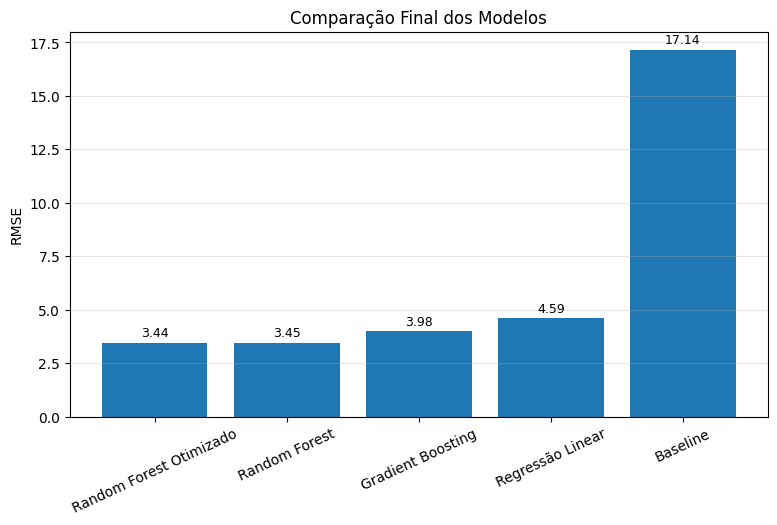

In [37]:
# Cria um gráfico de barras para comparar o RMSE dos modelos
plt.figure(figsize=(9,5))

bars = plt.bar(
    results_df.index,
    results_df["RMSE"]
)

# Adiciona os rótulos de dados sobre as barras
for bar in bars:
    plt.text(
        x=bar.get_x() + bar.get_width()/2,
        y=bar.get_height() + 0.15,
        s=f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Configura os elementos do gráfico
plt.ylabel("RMSE")
plt.title("Comparação Final dos Modelos")

# Rotaciona os nomes dos modelos para melhorar a visualização
plt.xticks(rotation=25)

# Adiciona linhas de grade para facilitar a comparação dos valores
plt.grid(axis="y", alpha=0.3)

# Exibe o gráfico
plt.show()

**Análise:** O gráfico confirma visualmente que o **Random Forest Otimizado** apresentou o menor RMSE entre os modelos avaliados, indicando o melhor desempenho final. A diferença em relação ao Random Forest original foi pequena, mas positiva. O **Gradient Boosting** e a **Regressão Linear** também apresentaram bons resultados, porém com erros superiores. Já o **baseline** apresentou RMSE muito mais elevado, reforçando que os modelos de Machine Learning agregaram capacidade preditiva ao problema.

#### **10.1.2 Comparação entre Valores Reais e Valores Previstos**

Nesta etapa é gerado um gráfico de dispersão para comparar os valores reais da variável alvo (PE) com os valores previstos pelo modelo otimizado. Essa visualização permite avaliar a qualidade das previsões e verificar o quão próximas elas estão dos valores observados. A linha diagonal representa o cenário ideal, em que o valor previsto é exatamente igual ao valor real.

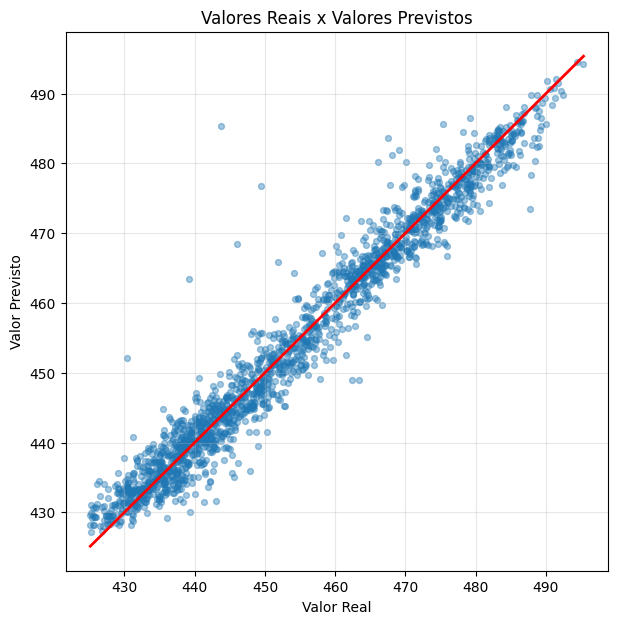

In [38]:
# Cria um gráfico de dispersão comparando valores reais e previstos
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4,
    s=18
)

# Adiciona a linha de referência (previsão perfeita)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

# Configura os elementos do gráfico
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais x Valores Previstos")

# Adiciona uma grade para facilitar a interpretação
plt.grid(alpha=0.3)

plt.show()

**Análise:** O gráfico mostra que os valores previstos pelo modelo ficaram muito próximos dos valores reais, uma vez que a maior parte das observações se concentra ao redor da linha de referência (previsão perfeita). Essa proximidade indica que o Random Forest Otimizado foi capaz de capturar adequadamente os padrões presentes nos dados, produzindo previsões com baixo erro. Embora existam alguns pontos mais distantes da linha, eles representam poucas observações e não comprometem o desempenho geral do modelo. Esse comportamento é consistente com as métricas obtidas anteriormente, reforçando a boa capacidade preditiva do modelo.

### **10.2 Análise da Distribuição dos Resíduos**

Nesta etapa é analisada a distribuição dos resíduos do modelo otimizado. Os resíduos representam a diferença entre os valores reais e os valores previstos, sendo uma importante ferramenta para avaliar a qualidade do ajuste do modelo. A análise da distribuição dos erros permite identificar possíveis vieses, assimetrias ou padrões que possam indicar limitações na capacidade preditiva do algoritmo.

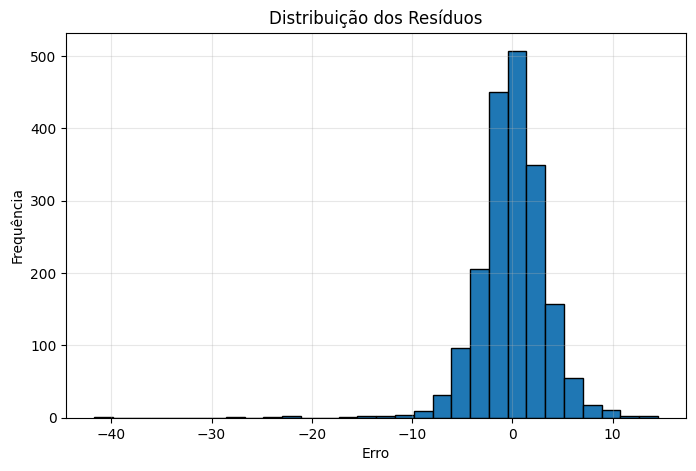

In [39]:
# Calcula os resíduos (erro de previsão)
residuals = y_test - y_pred

# Cria o histograma da distribuição dos resíduos
plt.figure(figsize=(8,5))
plt.hist(
    residuals,
    bins=30,
    edgecolor="black"
)

# Configura os elementos do gráfico
plt.title("Distribuição dos Resíduos")
plt.xlabel("Erro")
plt.ylabel("Frequência")

# Adiciona uma grade para facilitar a visualização
plt.grid(alpha=0.3)

# Exibe o gráfico
plt.show()

**Análise:** A distribuição dos resíduos está concentrada em torno de zero, indicando que, na maior parte das previsões, os erros foram pequenos. O formato aproximadamente simétrico do histograma sugere que o modelo não apresenta tendência consistente de superestimar ou subestimar a potência elétrica gerada. Embora existam alguns resíduos mais extremos, eles representam poucas observações e não comprometem o desempenho geral do modelo. Esses resultados reforçam que o Random Forest Otimizado apresentou um bom ajuste aos dados e produziu previsões consistentes.

### **10.3 Análise da Importância das Variáveis**

Nesta etapa é analisada a importância das variáveis explicativas no modelo Random Forest Otimizado. Essa análise permite identificar quais atributos contribuíram de forma mais significativa para a previsão da potência elétrica gerada (PE), auxiliando na interpretação do modelo e na compreensão da influência de cada variável sobre a variável alvo.

In [40]:
# Obtém o modelo Random Forest treinado dentro do Pipeline
rf = best_model.named_steps["model"]

# Cria a tabela de importância das variáveis
importance = (
    pd.DataFrame({
        "Variável": X.columns,
        "Importância": rf.feature_importances_
    })
    .sort_values(by="Importância", ascending=False)
    .reset_index(drop=True)
)

# Converte a importância para percentual
importance["Importância (%)"] = (
    importance["Importância"] * 100
).round(2)

# Exibe a soma das importâncias para validação
print(f"Soma das importâncias: {importance['Importância'].sum():.4f}")

# Mantém apenas as colunas que serão apresentadas no relatório
importance = importance[["Variável", "Importância (%)"]]

# Exibe a tabela
display(importance)

Soma das importâncias: 1.0000


,Variável,Importância (%)
0,AT,90.08
1,V,6.23
2,AP,1.92
3,RH,1.76


**Análise:** A análise de importância das variáveis mostra que a **Temperatura Ambiente (AT)** foi o atributo mais relevante para o modelo, representando aproximadamente **90% da importância total**. O **Vácuo de Exaustão (V)** aparece em seguida, com contribuição bem menor, enquanto **AP** e **RH** tiveram influência reduzida. Esse resultado está coerente com as análises anteriores, que já indicavam forte relação entre a temperatura ambiente e a potência elétrica gerada.

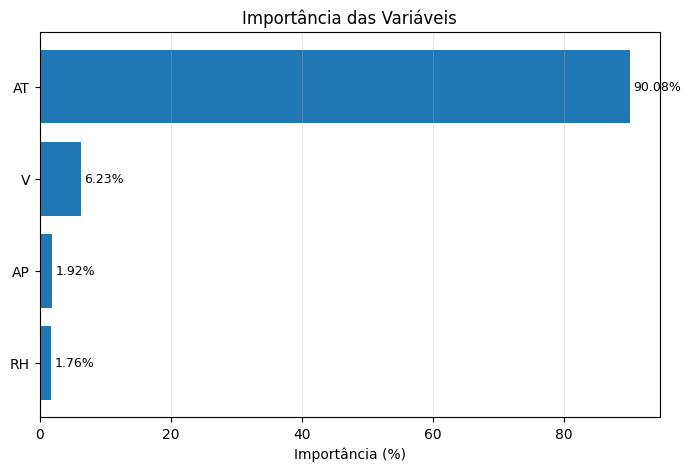

In [41]:
# Cria um gráfico de barras horizontais com a importância das variáveis
plt.figure(figsize=(8,5))

bars = plt.barh(
    importance["Variável"],
    importance["Importância (%)"]
)

# Exibe a variável mais importante no topo do gráfico
plt.gca().invert_yaxis()

# Adiciona os rótulos de dados
for bar in bars:

    largura = bar.get_width()

    plt.text(
        largura + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{largura:.2f}%",
        va="center",
        fontsize=9
    )

# Configura os elementos do gráfico
plt.xlabel("Importância (%)")
plt.title("Importância das Variáveis")

# Adiciona linhas de grade para facilitar a comparação
plt.grid(axis="x", alpha=0.3)

# Exibe o gráfico
plt.show()

**Análise:** O gráfico reforça que a **Temperatura Ambiente (AT)** foi, de longe, a variável mais importante para o modelo, representando aproximadamente **90% da importância total**. O **Vácuo de Exaustão (V)** também contribuiu para as previsões, porém com influência significativamente menor. Já a **Pressão Atmosférica (AP)** e a **Umidade Relativa (RH)** tiveram participação reduzida. Esses resultados mostram que a temperatura ambiente é o principal fator utilizado pelo Random Forest para estimar a potência elétrica gerada, estando em concordância com as análises de correlação e com o comportamento esperado para uma usina termelétrica de ciclo combinado.

## **11. Discussão dos Resultados**

O baseline apresentou o desempenho esperado para um modelo que utiliza apenas a média da variável-alvo.

A Regressão Linear serviu como referência inicial, permitindo comparar modelos lineares com modelos baseados em árvores.

Random Forest e Gradient Boosting apresentaram desempenho superior ao baseline, evidenciando que existem relações não lineares entre as variáveis ambientais e a potência elétrica gerada.

Após a otimização dos hiperparâmetros, o Random Forest apresentou melhora adicional, justificando sua escolha como modelo final.

## **12. Limitações**

Embora os resultados obtidos sejam satisfatórios, este MVP apresenta algumas limitações:

- o dataset representa apenas uma usina termelétrica;
- existem apenas quatro variáveis explicativas;
- não foram consideradas variáveis operacionais como carga, despacho ou manutenção;
- variáveis econômicas, como PLD e CMO, não estão disponíveis;
- o modelo não considera dependência temporal entre as observações.

Essas limitações representam oportunidades para trabalhos futuros.

## **13. Conclusão**

O objetivo deste MVP foi desenvolver um modelo capaz de prever a potência elétrica líquida gerada por uma usina termelétrica de ciclo combinado a partir de variáveis ambientais, utilizando técnicas de Machine Learning.

Para isso, foi utilizado o dataset Combined Cycle Power Plant, originalmente disponibilizado pelo UCI Machine Learning Repository e disponibilizado neste trabalho por meio de um repositório público no GitHub, garantindo que o notebook possa ser reproduzido integralmente.

Ao longo do projeto, foi possível percorrer todas as etapas de um fluxo típico de Machine Learning: desde a compreensão do problema e análise exploratória dos dados até a preparação da base, treinamento dos modelos e avaliação dos resultados. A análise inicial mostrou que o conjunto de dados possui boa qualidade, sem valores ausentes ou inconsistências relevantes, permitindo concentrar os esforços na comparação dos algoritmos.

Os modelos avaliados demonstraram que as variáveis ambientais disponíveis conseguem explicar boa parte da variação da potência gerada pela usina. Em especial, os modelos baseados em árvores apresentaram desempenho superior ao baseline e à Regressão Linear, evidenciando sua capacidade de capturar relações mais complexas entre as variáveis do problema.

Além de comparar diferentes algoritmos, a otimização do modelo Random Forest por meio do GridSearchCV permitiu buscar uma configuração mais adequada para o conjunto de dados, reforçando a importância do ajuste de hiperparâmetros no desempenho final do modelo.

Apesar do excelente desempenho obtido, o modelo foi treinado utilizando uma base relativamente pequena e controlada, composta por apenas quatro variáveis ambientais. Em aplicações reais, outros fatores operacionais podem influenciar a potência elétrica gerada e poderiam ser incorporados em trabalhos futuros para aumentar ainda mais a capacidade preditiva do modelo.

De forma geral, os resultados mostram que técnicas de Machine Learning podem ser utilizadas com sucesso para estimar a potência elétrica gerada em uma usina termelétrica de ciclo combinado. Embora este trabalho tenha sido desenvolvido com fins acadêmicos, a metodologia empregada é compatível com aplicações reais, podendo apoiar estudos de eficiência operacional, planejamento energético e análise de desempenho de usinas.